# ODDS Datasets Preview Notebook

This notebook previews and validates ODDS datasets before deeper modeling.

It follows this workflow:
1. Set up environment and paths
2. Load ODDS datasets into DataFrames
3. Inspect shapes and schemas
4. Preview rows
5. Check data quality
6. Build quick descriptive summaries
7. Apply sample filters
8. Export a compact preview report

## 1. Set Up Environment and Paths
Import libraries and define dataset names and root paths.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets.odds_dataset import ODDSDataset

DATA_ROOT = Path("data")
DATASET_NAMES = [
    "arrhythmia",
    "cardio",
    "satellite",
    "satimage-2",
    "shuttle",
    "thyroid",
]

# Optional glob patterns if you later add CSV/Parquet odds files.
CSV_PATTERN = "*.csv"
PARQUET_PATTERN = "*.parquet"

print(f"Data root: {DATA_ROOT.resolve()}")
print(f"Datasets: {DATASET_NAMES}")

Data root: D:\Workspace\Research\StatiscalLearning\semi_supervised_ad\data
Datasets: ['arrhythmia', 'cardio', 'satellite', 'satimage-2', 'shuttle', 'thyroid']


## 2. Load Odds Datasets into DataFrames
Load each ODDS dataset train/test split and collect status rows.

In [2]:
loaded = {}
load_status = []

for name in DATASET_NAMES:
    for split in ["train", "test"]:
        is_train = split == "train"
        ds = ODDSDataset(
            root=str(DATA_ROOT),
            dataset_name=name,
            train=is_train,
            random_state=0,
            download=is_train,
        )

        X = ds.data.detach().cpu().numpy()
        y = ds.targets.detach().cpu().numpy().astype(int)

        df = pd.DataFrame(X)
        df["label"] = y
        df["dataset"] = name
        df["split"] = split

        loaded[(name, split)] = df
        load_status.append(
            {
                "dataset": name,
                "split": split,
                "rows": len(df),
                "features": X.shape[1],
                "n_normal": int((y == 0).sum()),
                "n_anomaly": int((y == 1).sum()),
            }
        )

status_df = pd.DataFrame(load_status).sort_values(["dataset", "split"]).reset_index(drop=True)
status_df

,dataset,split,rows,features,n_normal,n_anomaly
0,arrhythmia,test,182,274,155,27
1,arrhythmia,train,270,274,231,39
2,cardio,test,733,21,662,71
3,cardio,train,1098,21,993,105
4,satellite,test,2575,36,1760,815
5,satellite,train,3860,36,2639,1221
6,satimage-2,test,2322,36,2293,29
7,satimage-2,train,3481,36,3439,42
8,shuttle,test,19640,9,18235,1405
9,shuttle,train,29457,9,27351,2106


## 3. Inspect Dataset Shapes and Column Schemas
Compare row counts and schema consistency across files/splits.

In [3]:
schema_map = {}
for key, df in loaded.items():
    schema_map[key] = tuple(df.columns)

unique_schema_count = len(set(schema_map.values()))
print(f"Unique schema patterns: {unique_schema_count}")
print("\nRows/columns per dataset split:")
print(status_df[["dataset", "split", "rows", "features"]].to_string(index=False))

Unique schema patterns: 5

Rows/columns per dataset split:
   dataset split  rows  features
arrhythmia  test   182       274
arrhythmia train   270       274
    cardio  test   733        21
    cardio train  1098        21
 satellite  test  2575        36
 satellite train  3860        36
satimage-2  test  2322        36
satimage-2 train  3481        36
   shuttle  test 19640         9
   shuttle train 29457         9
   thyroid  test  1510         6
   thyroid train  2262         6


## 4. Preview Rows and Key Odds Columns
Show head/tail/random samples and inspect potential odds-like columns if present.

In [4]:
selected_dataset = "cardio"
selected_split = "train"
preview_df = loaded[(selected_dataset, selected_split)].copy()

print("Head:")
display(preview_df.head())
print("Tail:")
display(preview_df.tail())
print("Random sample:")
display(preview_df.sample(5, random_state=0))

core_odds_cols = [
    c for c in ["event", "market", "bookmaker", "decimal_odds", "odds"]
    if c in preview_df.columns
]
if core_odds_cols:
    print("Core odds columns found:", core_odds_cols)
    display(preview_df[core_odds_cols].head())
else:
    print("No event/market/bookmaker/odds columns found in ODDS anomaly benchmark tables.")

Head:


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,label,dataset,split
0,0.339623,0.716456,0.00000,0.424051,0.000000,0.0,0.0,0.293333,0.131148,0.0,...,0.200000,0.0,0.547619,0.55,0.53,0.018587,0.5,0,cardio,train
1,0.641509,0.000000,0.00000,0.520995,0.423708,0.0,0.0,0.306667,0.622951,0.0,...,0.600000,0.1,0.658730,0.62,0.65,0.100372,1.0,0,cardio,train
2,0.320755,0.250998,0.01384,0.000000,0.000000,0.0,0.0,0.586667,0.081967,0.0,...,0.266667,0.0,0.531746,0.54,0.53,0.014870,1.0,0,cardio,train
3,0.283019,0.246087,0.00000,0.582609,0.148068,0.0,0.0,0.160000,0.213115,0.0,...,0.133333,0.0,0.476190,0.50,0.45,0.059480,0.5,0,cardio,train
4,0.660377,0.353750,0.00000,0.418750,0.000000,0.0,0.0,0.613333,0.180328,0.0,...,0.400000,0.1,0.650794,0.67,0.69,0.029740,0.5,0,cardio,train


Tail:


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,label,dataset,split
1093,0.528302,0.172036,0.000000,0.000000,0.000000,0.0,0.852584,0.706667,0.262295,0.000000,...,0.533333,0.1,0.222222,0.25,0.23,0.308550,0.0,1,cardio,train
1094,0.452830,0.000000,0.734325,0.000000,0.000000,0.0,1.000000,0.906667,0.016393,0.000000,...,0.066667,0.0,0.380952,0.45,0.42,0.085502,0.0,1,cardio,train
1095,0.264151,0.000000,0.000000,0.309612,0.692442,0.0,0.345656,0.693333,0.245902,0.000000,...,0.666667,0.1,0.206349,0.17,0.24,0.159851,0.0,1,cardio,train
1096,0.830189,0.000000,0.002789,0.000000,0.000000,0.0,0.000000,0.960000,0.016393,0.351648,...,0.000000,0.0,0.714286,0.75,0.73,0.003717,1.0,1,cardio,train
1097,0.415094,0.000000,0.003216,0.465997,0.315817,0.0,0.433539,0.720000,0.409836,0.000000,...,0.266667,0.0,0.357143,0.14,0.34,0.078067,0.5,1,cardio,train


Random sample:


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,label,dataset,split
944,0.433962,0.678425,0.000000,0.573630,0.000000,0.0,0.0,0.146667,0.229508,0.000000,...,0.266667,0.0,0.619048,0.68,0.66,0.048327,0.5,0,cardio,train
27,0.698113,0.000000,0.000000,0.065239,0.000000,0.0,0.0,0.760000,0.016393,0.065934,...,0.066667,0.0,0.674603,0.69,0.68,0.003717,0.5,0,cardio,train
425,0.471698,0.749669,0.000000,0.354967,0.000000,0.0,0.0,0.213333,0.180328,0.000000,...,0.466667,0.0,0.658730,0.71,0.68,0.029740,1.0,0,cardio,train
494,0.301887,0.000000,0.000000,0.344650,0.210219,0.0,0.0,0.160000,0.213115,0.000000,...,0.066667,0.2,0.507937,0.44,0.45,0.044610,0.5,0,cardio,train
196,0.509434,0.000000,0.004259,0.480041,0.278858,0.0,0.0,0.640000,0.327869,0.000000,...,0.066667,0.0,0.595238,0.49,0.54,0.070632,1.0,0,cardio,train


No event/market/bookmaker/odds columns found in ODDS anomaly benchmark tables.


## 5. Check Data Types, Missing Values, and Duplicates
Run quick quality checks and perform safe type conversions where possible.

In [5]:
quality_rows = []

for (name, split), df in loaded.items():
    work = df.copy()

    if "timestamp" in work.columns:
        work["timestamp"] = pd.to_datetime(work["timestamp"], errors="coerce")
    for col in ["event", "market", "bookmaker", "dataset", "split"]:
        if col in work.columns:
            work[col] = work[col].astype("category")

    missing = int(work.isna().sum().sum())
    duplicates = int(work.duplicated().sum())

    quality_rows.append(
        {
            "dataset": name,
            "split": split,
            "missing_values": missing,
            "duplicate_rows": duplicates,
        }
    )

quality_df = pd.DataFrame(quality_rows).sort_values(["dataset", "split"]).reset_index(drop=True)
quality_df

,dataset,split,missing_values,duplicate_rows
0,arrhythmia,test,0,0
1,arrhythmia,train,0,0
2,cardio,test,0,2
3,cardio,train,0,2
4,satellite,test,0,0
5,satellite,train,0,0
6,satimage-2,test,0,1
7,satimage-2,train,0,0
8,shuttle,test,0,0
9,shuttle,train,0,0


In [9]:
# Check whether each dataset split contains categorical columns
categorical_rows = []

for (name, split), df in loaded.items():
    cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    categorical_rows.append(
        {
            "dataset": name,
            "split": split,
            "has_categorical": len(cat_cols) > 0,
            "n_categorical_cols": len(cat_cols),
            "categorical_columns": ", ".join(cat_cols) if cat_cols else "",
        }
    )

categorical_df = pd.DataFrame(categorical_rows).sort_values(["dataset", "split"]).reset_index(drop=True)
categorical_df

,dataset,split,has_categorical,n_categorical_cols,categorical_columns
0,arrhythmia,test,True,2,"dataset, split"
1,arrhythmia,train,True,2,"dataset, split"
2,cardio,test,True,2,"dataset, split"
3,cardio,train,True,2,"dataset, split"
4,satellite,test,True,2,"dataset, split"
5,satellite,train,True,2,"dataset, split"
6,satimage-2,test,True,2,"dataset, split"
7,satimage-2,train,True,2,"dataset, split"
8,shuttle,test,True,2,"dataset, split"
9,shuttle,train,True,2,"dataset, split"


## 6. Create Quick Descriptive Summaries for Odds Fields
Compute summary stats for odds-like columns and implied probabilities where available.

In [6]:
summary_rows = []

for (name, split), df in loaded.items():
    numeric_cols = [c for c in df.columns if c not in {"label", "dataset", "split"}]

    # For ODDS benchmark tables, features are generic numeric dimensions.
    # We treat the first feature as an odds-like proxy only when explicit odds columns are missing.
    odds_col = None
    for candidate in ["decimal_odds", "odds"]:
        if candidate in df.columns:
            odds_col = candidate
            break

    if odds_col is None and len(numeric_cols) > 0:
        odds_col = numeric_cols[0]

    if odds_col is None:
        continue

    s = pd.to_numeric(df[odds_col], errors="coerce").dropna()
    if s.empty:
        continue

    valid = s[s > 0]
    implied_prob = 1.0 / valid

    summary_rows.append(
        {
            "dataset": name,
            "split": split,
            "odds_column": odds_col,
            "count": int(valid.shape[0]),
            "odds_min": float(valid.min()),
            "odds_q25": float(valid.quantile(0.25)),
            "odds_median": float(valid.median()),
            "odds_q75": float(valid.quantile(0.75)),
            "odds_max": float(valid.max()),
            "implied_p_mean": float(implied_prob.mean()),
            "implied_p_min": float(implied_prob.min()),
            "implied_p_max": float(implied_prob.max()),
        }
    )

summary_df = pd.DataFrame(summary_rows).sort_values(["dataset", "split"]).reset_index(drop=True)
summary_df

,dataset,split,odds_column,count,odds_min,odds_q25,odds_median,odds_q75,odds_max,implied_p_mean,implied_p_min,implied_p_max
0,arrhythmia,test,0,181,0.075949,0.455696,0.582278,0.734177,1.037975,2.092514,0.963415,13.166667
1,arrhythmia,train,0,268,0.025316,0.443038,0.569620,0.712025,1.000000,2.303666,1.000000,39.500000
2,cardio,test,0,729,0.075472,0.377358,0.490566,0.622642,1.018868,2.405270,0.981481,13.250000
3,cardio,train,0,1095,0.075472,0.358491,0.490566,0.603774,1.000000,2.509618,1.000000,13.250000
4,satellite,test,0,2568,0.015625,0.312500,0.437500,0.625000,0.953125,3.520967,1.049180,64.000000
5,satellite,train,0,3858,0.015625,0.312500,0.437500,0.625000,1.000000,3.394091,1.000000,64.000000
6,satimage-2,test,0,2322,0.016129,0.370968,0.483871,0.677419,1.032258,2.444813,0.968750,62.000000
7,satimage-2,train,0,3480,0.048387,0.370968,0.483871,0.677419,1.000000,2.438033,1.000000,20.666668
8,shuttle,test,0,19638,0.090909,0.101010,0.171717,0.232323,0.969697,6.359982,1.031250,11.000000
9,shuttle,train,0,29456,0.090909,0.101010,0.171717,0.232323,1.000000,6.355818,1.000000,11.000000


## 7. Sample Filters for Date, League, and Market
Reusable filtering helpers for odds-style tables (works as no-op on ODDS benchmark schema).

In [7]:
def filter_preview(df, start_date=None, end_date=None, league=None, market=None):
    out = df.copy()

    if start_date is not None and "date" in out.columns:
        out = out[pd.to_datetime(out["date"], errors="coerce") >= pd.to_datetime(start_date)]
    if end_date is not None and "date" in out.columns:
        out = out[pd.to_datetime(out["date"], errors="coerce") <= pd.to_datetime(end_date)]
    if league is not None and "league" in out.columns:
        out = out[out["league"] == league]
    if market is not None and "market" in out.columns:
        out = out[out["market"] == market]

    return out

filtered = filter_preview(preview_df, start_date="2020-01-01", market="1X2")
print(f"Filtered rows: {len(filtered)}")
display(filtered.head())

Filtered rows: 1098


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,label,dataset,split
0,0.339623,0.716456,0.00000,0.424051,0.000000,0.0,0.0,0.293333,0.131148,0.0,...,0.200000,0.0,0.547619,0.55,0.53,0.018587,0.5,0,cardio,train
1,0.641509,0.000000,0.00000,0.520995,0.423708,0.0,0.0,0.306667,0.622951,0.0,...,0.600000,0.1,0.658730,0.62,0.65,0.100372,1.0,0,cardio,train
2,0.320755,0.250998,0.01384,0.000000,0.000000,0.0,0.0,0.586667,0.081967,0.0,...,0.266667,0.0,0.531746,0.54,0.53,0.014870,1.0,0,cardio,train
3,0.283019,0.246087,0.00000,0.582609,0.148068,0.0,0.0,0.160000,0.213115,0.0,...,0.133333,0.0,0.476190,0.50,0.45,0.059480,0.5,0,cardio,train
4,0.660377,0.353750,0.00000,0.418750,0.000000,0.0,0.0,0.613333,0.180328,0.0,...,0.400000,0.1,0.650794,0.67,0.69,0.029740,0.5,0,cardio,train


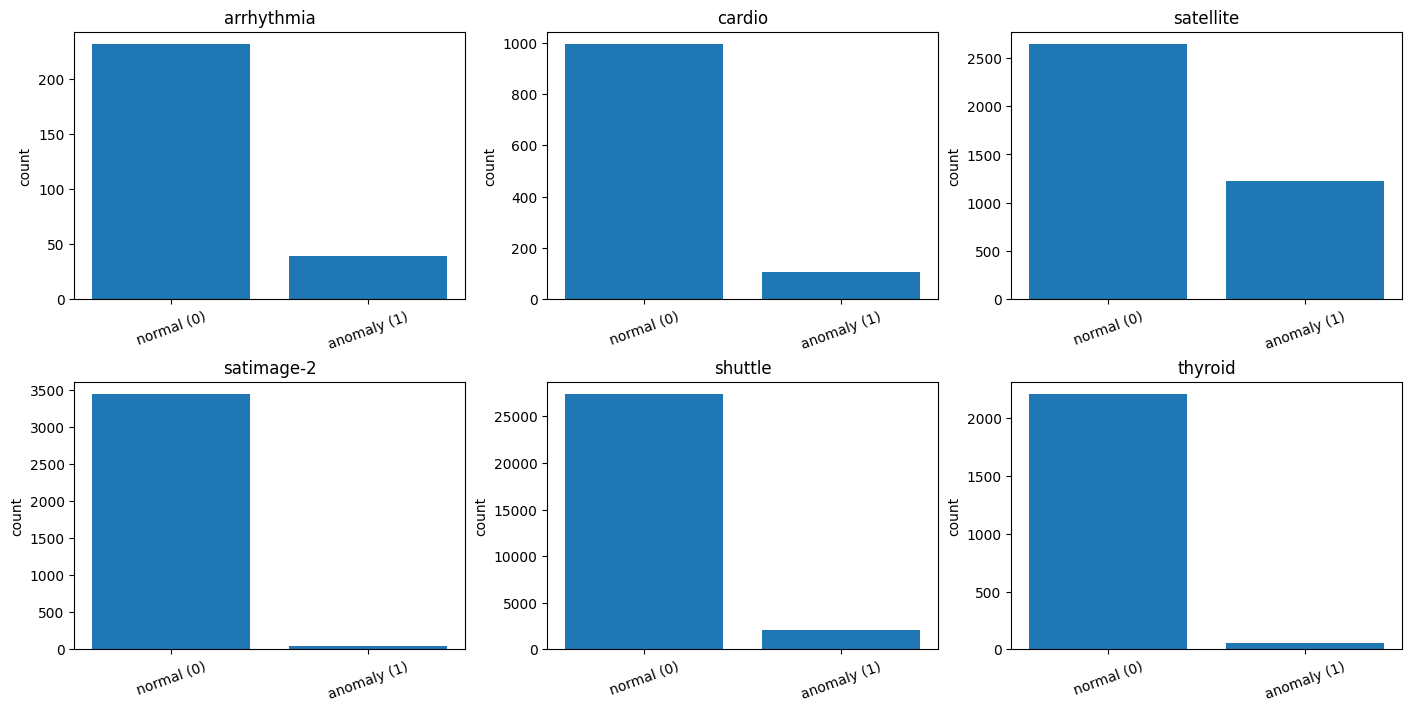

In [8]:
# Class distribution plots (quick visual sanity check)
fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)
axes = axes.ravel()

for i, name in enumerate(DATASET_NAMES):
    ax = axes[i]
    df = loaded[(name, "train")]
    counts = df["label"].value_counts().sort_index()
    labels = ["normal (0)", "anomaly (1)"]
    yvals = [counts.get(0, 0), counts.get(1, 0)]
    ax.bar(labels, yvals)
    ax.set_title(name)
    ax.set_ylabel("count")
    ax.tick_params(axis="x", rotation=20)

plt.show()